In [3]:
#soal no 1
import threading
import time

# --- TANPA LOCK (Mengamati Race Condition) ---
saldo = 1_000_000

def transaksi_tanpa_lock(jumlah_transaksi):
    global saldo
    for _ in range(jumlah_transaksi):
        # --- TARIK 1 ---
        temp_tarik = saldo
        time.sleep(0)       
        saldo = temp_tarik - 1

        # --- SETOR 1 ---
        temp_setor = saldo
        time.sleep(0)    
        saldo = temp_setor + 1

SALDO_AWAL = 1_000_000
JUMLAH_THREAD = 10
JUMLAH_TRANSAKSI = 10_000

saldo = SALDO_AWAL
threads = [
    threading.Thread(target=transaksi_tanpa_lock, args=(JUMLAH_TRANSAKSI,)) 
    for _ in range(JUMLAH_THREAD)
]

for t in threads:
    t.start()
for t in threads:
    t.join()

saldo_seharusnya = SALDO_AWAL
print(f"Saldo awal             : Rp {SALDO_AWAL:,}")
print(f"Saldo akhir seharusnya : Rp {saldo_seharusnya:,}")
print(f"Saldo akhir aktual     : Rp {saldo:,}")
print(f"Selisih (Data corrupt) : Rp {saldo_seharusnya - saldo:,}")

Saldo awal             : Rp 1,000,000
Saldo akhir seharusnya : Rp 1,000,000
Saldo akhir aktual     : Rp 999,999
Selisih (Data corrupt) : Rp 1


In [2]:
import threading

# --- DENGAN LOCK (Solusi Thread-Safe) ---
saldo = 1_000_000
lock = threading.Lock()

def transaksi_dengan_lock(jumlah_transaksi):
    global saldo
    for _ in range(jumlah_transaksi):
        with lock:         
            saldo -= 1
            saldo += 1
                            

SALDO_AWAL = 1_000_000
JUMLAH_THREAD = 10
JUMLAH_TRANSAKSI = 10_000

saldo = SALDO_AWAL
threads = [
    threading.Thread(target=transaksi_dengan_lock, args=(JUMLAH_TRANSAKSI,)) 
    for _ in range(JUMLAH_THREAD)
]

for t in threads:
    t.start()
for t in threads:
    t.join()

saldo_seharusnya = SALDO_AWAL
status = "✅ YA" if saldo == saldo_seharusnya else "❌ TIDAK"

print(f"Saldo awal             : Rp {SALDO_AWAL:,}")
print(f"Saldo akhir seharusnya : Rp {saldo_seharusnya:,}")
print(f"Saldo akhir aktual     : Rp {saldo:,}")
print(f"Sesuai? {status}")

Saldo awal             : Rp 1,000,000
Saldo akhir seharusnya : Rp 1,000,000
Saldo akhir aktual     : Rp 1,000,000
Sesuai? ✅ YA


In [ ]:
""" "Berdasarkan hasil pengujian pada program simulasi transaksi akun bank, terdapat perbedaan yang sangat jelas antara eksekusi tanpa kunci (lock) dan eksekusi dengan kunci (lock). Pada program tanpa menggunakan lock, saldo awal sebesar Rp 1.000.000 mengalami ketidaksesuaian nilai di mana saldo akhir aktual hanya tersisa Rp 999.999—sehingga terdapat selisih atau data corrupt sebesar Rp 1. Sebaliknya, ketika kita menerapkan mekanisme threading.Lock(), nilai saldo akhir secara konsisten kembali tepat ke angka Rp 1.000.000 tanpa ada selisih sedikit pun."

"Terjadinya kerusakan data pada program tanpa lock disebabkan oleh masalah race condition. Operasi transaksi seperti penarikan (saldo -= 1) dan penyetoran (saldo += 1) sebenarnya bukanlah operasi atomik atau operasi tunggal, melainkan terdiri dari tiga tahapan di tingkat prosesor, yaitu membaca nilai saldo saat ini, menghitung nilai baru, dan menuliskan kembali hasilnya ke memori. Ketika banyak thread berjalan bersamaan, sistem operasi dapat melakukan pergantian giliran (context switch) di tengah-tengah ketiga tahapan tersebut. Hal ini membuat sebuah thread membaca nilai saldo lama sebelum thread lain sempat menuliskan perubahan terbarunya. Akibat benturan waktu penulisan ini, hasil transaksi dari salah satu thread menjadi tertimpa (lost update)."

"Untuk memecahkan masalah benturan data tersebut, digunakanlah objek threading.Lock() yang menerapkan prinsip Mutual Exclusion (Mutex). Dengan membungkus kode transaksi di dalam blok critical section (with lock:), kita memastikan bahwa hanya ada satu thread saja yang diizinkan memegang kunci dan melakukan operasi pada variabel saldo dalam satu waktu. Thread lain yang ingin melakukan transaksi dipaksa mengantre hingga thread yang sedang berjalan selesai dan melepaskan kuncinya. Dengan isolasi transaksi ini, tidak ada lagi pembacaan atau penulisan data yang saling bertabrakan, sehingga integritas data saldo bank dapat terjaga secara sempurna.""""

In [4]:
#soal No 2
import threading
import queue
import time
import random

def producer(q, jumlah_item, nama="Producer"):
    for i in range(jumlah_item):
        item = f"item-{i}"
        time.sleep(random.uniform(0.05, 0.2))  # simulasi waktu produksi
        q.put(item)
        print(f"[{nama}] menghasilkan: {item}")
    
    # Mengirimkan sinyal None awal untuk memicu penghentian consumer
    q.put(None)

def consumer(q, nama="Consumer"):
    while True:
        item = q.get()
        if item is None:
            # Memasukkan kembali None ke antrean agar consumer lain juga menerima sinyal berhenti
            q.put(None)  
            q.task_done()
            print(f"    [{nama}] menerima sinyal selesai, berhenti.")
            break
        
        time.sleep(random.uniform(0.05, 0.15))  # simulasi waktu pemrosesan
        print(f"    [{nama}] memproses: {item}")
        q.task_done()

# Inisialisasi Queue bersama
q = queue.Queue()

# Membuat 1 Producer dan 3 Consumer
t_producer = threading.Thread(target=producer, args=(q, 9, "Producer-1"))
t_consumers = [
    threading.Thread(target=consumer, args=(q, f"Consumer-{i+1}"))
    for i in range(3)
]

# Menjalankan seluruh thread
t_producer.start()
for c in t_consumers:
    c.start()

# Menunggu seluruh thread selesai
t_producer.join()
for c in t_consumers:
    c.join()

print("\nSemua item telah diproduksi dan dikonsumsi secara aman oleh 3 consumer.")

[Producer-1] menghasilkan: item-0
[Producer-1] menghasilkan: item-1
    [Consumer-1] memproses: item-0
    [Consumer-2] memproses: item-1
[Producer-1] menghasilkan: item-2
[Producer-1] menghasilkan: item-3
    [Consumer-3] memproses: item-2
[Producer-1] menghasilkan: item-4
    [Consumer-1] memproses: item-3
    [Consumer-2] memproses: item-4
[Producer-1] menghasilkan: item-5
    [Consumer-3] memproses: item-5
[Producer-1] menghasilkan: item-6
    [Consumer-1] memproses: item-6
[Producer-1] menghasilkan: item-7
[Producer-1] menghasilkan: item-8
    [Consumer-1] menerima sinyal selesai, berhenti.
    [Consumer-2] memproses: item-7
    [Consumer-2] menerima sinyal selesai, berhenti.
    [Consumer-3] memproses: item-8
    [Consumer-3] menerima sinyal selesai, berhenti.

Semua item telah diproduksi dan dikonsumsi secara aman oleh 3 consumer.


In [ ]:
""" 
Pola Producer-Consumer ini memanfaatkan struktur data queue.Queue yang bersifat thread-safe secara internal
. Ketika producer memasukkan item ke dalam antrean, ketiga consumer (Consumer-1, Consumer-2, Consumer-3) secara otomatis berbagi beban kerja. Consumer yang sedang tidak sibuk (idle) akan langsung mengambil item berikutnya dari antrean tanpa risiko race condition atau pengambilan data ganda.

Untuk menghentikan seluruh consumer dengan rapi (graceful termination), digunakan nilai penanda khusus (sentinel value) berupa None
.
Producer hanya perlu memasukkan None satu kali setelah seluruh item habis diproduksi
.
Ketika Consumer-1 mengambil nilai None, ia akan mengembalikan nilai None tersebut ke dalam antrean (q.put(None)) tepat sebelum keluar dari perulangan (break)
.
Nilai None ini kemudian diambil oleh Consumer-2, yang juga mengembalikannya ke antrean sebelum berhenti
.
Proses ini berantai (
efek domino) hingga Consumer-3 mengambil nilai None dan akhirnya semua consumer dapat berhenti dengan sempurna tanpa ada thread yang terhambat (hanging)
.

Penggunaan q.task_done() pada setiap transaksi—termasuk saat memproses sinyal None—memastikan bahwa status penyelesaian tugas tercatat dengan akurat oleh antrean
. Hal ini menjaga keutuhan aliran data sehingga program utama dapat melakukan sinkronisasi join() secara aman dan bersih
.
"""

In [6]:
#Soal No 3
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import random

# 1. Inisialisasi 50 file simulasi dengan latensi acak (0.3 - 0.8 detik)
random.seed(42)
daftar_file = [f"file_{i}.dat" for i in range(50)]
latensi_simulasi = {f: random.uniform(0.3, 0.8) for f in daftar_file}

def download_file(nama_file):
    durasi = latensi_simulasi[nama_file]
    time.sleep(durasi)  # Simulasi latensi jaringan (I/O-bound)
    ukuran_kb = round(durasi * 1000)
    return f"{nama_file} ({ukuran_kb} KB)"

# 2. Pengujian dengan variasi max_workers = [2, 4, 8, 16]
workers_list = [2, 4, 8, 16]
waktu_eksekusi = []

print("=== EKSPERIMEN THREADPOOLEXECUTOR (50 FILE) ===")
for mw in workers_list:
    start = time.perf_counter()
    hasil_pool = []
    
    with ThreadPoolExecutor(max_workers=mw) as executor:
        future_ke_file = {executor.submit(download_file, f): f for f in daftar_file}
        for future in as_completed(future_ke_file):
            hasil_pool.append(future.result())
            
    durasi_total = time.perf_counter() - start
    waktu_eksekusi.append(durasi_total)
    print(f"max_workers = {mw:2d} -> Total Waktu: {durasi_total:.2f} detik")


=== EKSPERIMEN THREADPOOLEXECUTOR (50 FILE) ===
max_workers =  2 -> Total Waktu: 13.43 detik
max_workers =  4 -> Total Waktu: 6.85 detik
max_workers =  8 -> Total Waktu: 3.63 detik
max_workers = 16 -> Total Waktu: 2.10 detik


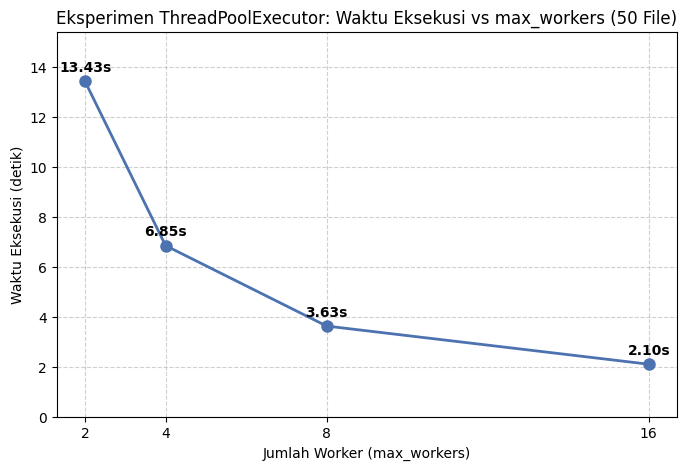

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(workers_list, waktu_eksekusi, marker="o", linewidth=2, color="#4C72B0", markersize=8)
plt.title("Eksperimen ThreadPoolExecutor: Waktu Eksekusi vs max_workers (50 File)", fontsize=12)
plt.xlabel("Jumlah Worker (max_workers)", fontsize=10)
plt.ylabel("Waktu Eksekusi (detik)", fontsize=10)
plt.xticks(workers_list)
plt.grid(True, linestyle="--", alpha=0.6)

# Menampilkan label angka waktu di atas titik grafik
for x, y in zip(workers_list, waktu_eksekusi):
    plt.text(x, y + 0.4, f"{y:.2f}s", ha="center", fontweight="bold")

plt.ylim(0, max(waktu_eksekusi) + 2)
plt.show()

In [ ]:
""" Berdasarkan data eksekusi dan grafik plot ThreadPoolExecutor:
max_workers = 2 : Membutuhkan waktu 13.43 detik.
max_workers = 4 : Waktu turun signifikan menjadi 6.85 detik (speedup ~1.96x).
max_workers = 8 : Waktu turun menjadi 3.63 detik (speedup ~3.70x dari 2 worker).
max_workers = 16 : Waktu mencapai 2.10 detik (speedup ~6.40x dari 2 worker).
Terlihat bahwa penambahan jumlah worker dari 2 hingga 16 secara konsisten memangkas total waktu pengunduhan 50 file simulasi.

 Menambah max_workers Terus-Menerus Tidak Selalu Mempercepat Proses. Meskipun dari 2 hingga 16 workers waktu eksekusi terus berkurang (dari 13.43s hingga 2.10s), menambah worker secara terus-menerus tidak akan memberikan percepatan tanpa batas. Pada titik tertentu, kurva efisiensi akan mengalami landai (plateau) atau bahkan menurun akibat titik jenuh.
Penyebab Munculnya Saturation Point itu adalah I/O Bottleneck. Dalam kondisi riil, kecepatan unduh dibatasi oleh lebar pita (bandwidth) jaringan dan kapasitas server target. Jika bandwidth sudah terpakai maksimal pada jumlah worker tertentu, menambah worker baru hanya akan membuat thread berebut jaringan yang sama tanpa menambah kecepatan total.
Alasan yang kedua adalah Thread Management Overhead & Context Switching: Setiap thread membutuhkan alokasi memori dan CPU overhead untuk dikelola. Jika jumlah worker dinaikkan terlalu ekstrem (misalnya 100+ workers), CPU akan menghabiskan lebih banyak waktu untuk context switching (berganti-ganti antar thread) dibandingkan melakukan tugas I/O itu sendiri.
dan yang lainya adalah Interupsi GIL (Global Interpreter Lock). Meskipun tugas I/O melepaskan GIL saat menunggu respons (time.sleep), operasi tingkat lanjut di sekitar thread (seperti eksekusi loop, parsing, dan manajemen antrean ThreadPoolExecutor) tetap membutuhkan giliran GIL di Python.
Batas Sumber Daya Sistem Operasi: Sistem operasi memiliki batasan jumlah file descriptor dan socket jaringan yang dapat dibuka secara bersamaan. """

In [ ]:
""""
SOal no 4
Kasus di mana Threading Membantu (I/O-Bound Task):
Aplikasi Web Crawler / Scraper yang mengambil halaman web dari ratusan URL secara bersamaan
. Karena sebagian besar durasi dihabiskan untuk menunggu respons server (I/O wait), threading memungkinkan CPU berpindah mengerjakan permintaan lain saat menunggu latensi jaringan tanpa terhambat Global Interpreter Lock (GIL)
.
Kasus di mana Threading Tidak Membantu (CPU-Bound Task):
Aplikasi Rendering atau Konversi Video 4K (seperti pemrosesan matriks frame gambar). Tugas ini murni membutuhkan komputasi matematika intensif pada CPU
. Akibat batasan GIL pada Python yang hanya mengizinkan satu thread mengeksekusi kode dalam satu waktu, threading tidak akan mempercepat proses dan tidak bisa memanfaatkan multi-core CPU secara simultan
. Kasus ini memerlukan multiprocessing agar setiap proses berjalan di core fisik/logis terpisah
.
"""
